# Fine-tuning U-Net architecture
Modèles basés sur l'architeture U-Net :
- U-Net avec encodeur ResNet34
- ResAttentionUNetPlusPlus
- Attention Gated Multi ResU-Net
- EggSegmentationHVUNet

In [1]:
import os
import numpy as np
import torch
import torch.optim as optim
import pickle 
import time
import sys
import pandas as pd
import random

from torch.utils.data import DataLoader
from matplotlib import pyplot as plt
import segmentation_models_pytorch as smp
from pathlib import Path
from sklearn.model_selection import GroupKFold, StratifiedGroupKFold

sys.path.append(str(Path.cwd().parent)) # Ajoute le dossier parent au chemin de recherche de Python

# Importation des classes de dataset personnalisées
from utils.dataset_unet import RoboflowUNetDataset, EggHVDataset

# Importation des fonctions utilitaires
from utils.models_config import collate_fn, collate_fn_egg_hv, split_dataset, dataset_to_dict, metrics_by_class, save_validation_masks, save_validation_overlays
from utils.post_traitement import keep_largest_components, fill_holes, split_eggs
from utils.stats_fct import plot_segmentation_comparison
from utils.fonctions_de_perte import BCE_DiceLoss, BCE_DiceLoss_ignore, BCE_Dice_ContourLoss_ignore

# Importation des modèles U-Net personnalisés
from models.ResAttentionUNetPlusPlus import ResAttentionUNetPlusPlus
from models.AttentionMultiResUNet import AttentionMultiResUNet
from models.EggSegmentationHVUNet import (EggSegmentationHVUNet, EggSegmentationHVLoss, postprocess_egg_instances)

/home/ldepiero/Stage-GonAIde-2026/mon_venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Reproductibilité du code

In [2]:
# Seed global pour la reproductibilité
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Déterminisme complet des opérations cuDNN (au prix d'un léger ralentissement)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

### =========== Choix du modèle ===========

In [19]:
MODEL_NAME = "UNet" # UNet, AttentionUNet++, MultiResUnet ou EggSegmentationHVUNet

### =========== Choix des données ===========

In [20]:
DATASET_NAME = "oeufs"  # "3classes" ou "2classses" ou "oeufs"

### Importation et traitement des données

In [21]:
# -------- 1. Importation des images et annotations --------
DATASET_CONFIG = {
    "2classes": {"images": "../data/COCO/images", "annotations": "../data/COCO/annotations_2_classes.json"},
    "3classes": {"images": "../data/COCO/images", "annotations": "../data/COCO/annotations.json"},
    "oeufs": {"images": "../data/COCO/oeufs", "annotations": "../data/COCO/annotations.oeufs.json"},
}
images_dir = DATASET_CONFIG[DATASET_NAME]["images"]
annotations_json = DATASET_CONFIG[DATASET_NAME]["annotations"]
masks_dir = f"masks/eval/{MODEL_NAME}/{DATASET_NAME}"
results_dir = f"results/eval/{MODEL_NAME}/{DATASET_NAME}"

# ------- 2. Importation du Data Frame avec les metadata --------
df = pd.read_excel("../utils/correspondance_echo_final.xlsx", dtype={"annee" : str, "image_id": str, "new_name_file": str})

# -------- 3. Préparation du dataset --------
# Transformation du dataset en dictionnaire et récupération des informations nécessaires pour l'entraînement et l'évaluation
all_samples, categories, num_classes, class_ids, ignore_category_id = dataset_to_dict(df, annotations_json, images_dir)

# Gestion de la classe "Ignore Gonade" si présente dans le dataset
gonade_id = class_ids.index(next((cid for cid, name in categories.items() if name == "Gonade"), class_ids[0])) if ignore_category_id is not None else None

class_names = [categories[cid] for cid in class_ids]
print(f"Model : {MODEL_NAME}, Dataset : {DATASET_NAME}, classes={class_names}")

Classes détectées (1) : {2: 'Oeuf'}
Model : UNet, Dataset : oeufs, classes=['Oeuf']


### Division du jeu de données

In [22]:
IMAGE_SIZE = (512, 512)

cv_samples, test_samples, cv_categories, test_categories, groups_train, groups_test, cv_dataset, test_dataset = split_dataset(all_samples, images_dir, df, IMAGE_SIZE, num_classes, 
                                                                                                                              class_ids, dim="2", # dim = "2" car images 2D                                                                                                                                                                                                                                                                                                                                                               
                                                                                                                              ignore_category_id=ignore_category_id, # ID de la classe "Ignore" si présente
                                                                                                                                ignore_target_class_idx=gonade_id) # ID de la classe "Gonade" si présente

print(f"Shape des images: {test_dataset[0]['image'].shape}")

Nombre total d'images valides : 69
Échantillons train/val        : 57
Échantillons de test          : 12
Shape des images: torch.Size([3, 512, 512])


### Définition création du modèle et du dataset

In [23]:
def build_model():
    """Construit le modèle sans télécharger de poids d'encodeur."""
    if MODEL_NAME == "EggSegmentationHVUNet":
        if DATASET_NAME != "oeufs":
            raise ValueError("EggSegmentationHVUNet nécessite DATASET_NAME='oeufs'")
        return EggSegmentationHVUNet(in_channels=nb_channels, encoder_weights="imagenet")
    if MODEL_NAME == "UNet":
        return smp.Unet(
            encoder_name="resnet34", encoder_weights="imagenet",
            in_channels=nb_channels, classes=num_classes, activation=None,
        )
    if MODEL_NAME == "AttentionUNet++":
        return ResAttentionUNetPlusPlus(
            num_classes=num_classes, in_channels=nb_channels, encoder_weights="imagenet"
        )
    if MODEL_NAME == "MultiResUnet":
        return AttentionMultiResUNet(in_ch=nb_channels, num_classes=num_classes)
    raise ValueError(f"Modèle inconnu : {MODEL_NAME}")

def build_dataset(samples, is_train=False):
    if MODEL_NAME == "EggSegmentationHVUNet":
        if DATASET_NAME != "oeufs":
                    raise ValueError("EggSegmentationHVUNet nécessite DATASET_NAME='oeufs'")
        if not class_ids:
            raise ValueError("Aucune catégorie COCO disponible pour EggSegmentationHVUNet")
        return EggHVDataset(
            samples=samples, image_size=IMAGE_SIZE, is_train=is_train,
            egg_category_id=class_ids[0],
        ), collate_fn_egg_hv
    dataset = RoboflowUNetDataset(
        samples=samples, image_dir=images_dir, df=df, image_size=IMAGE_SIZE,
        num_classes=num_classes, class_ids=class_ids, is_train=is_train,
        ignore_category_id=ignore_category_id, ignore_target_class_idx=gonade_id,
    )
    return dataset, collate_fn

### Hyperparamètres du modèle et initialisation

In [24]:
os.makedirs(masks_dir, exist_ok=True)
os.makedirs(results_dir, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Utilisation de l'appareil: {device}")

# ---- 1. Hyperparamètres ----
epochs = 150
nb_channels = cv_dataset[0]['image'].shape[0]  # Nombre de canaux d'entrée
learning_rate = 1e-4

# ---- 2. Fonctions de perte ----
if MODEL_NAME == "EggSegmentationHVUNet":
    loss_fn = EggSegmentationHVLoss(mask_weight=10.0, hv_weight=1.0)
else:
    loss_fn = BCE_Dice_ContourLoss_ignore(bce_weight=0.5, dice_weight=0.5, contour_weight=0, ignore_index=-100)

# ---- 3. Early stopping config ----
early_stopping_patience = 10  # nombre d'epochs sans amélioration avant arrêt
early_stopping_min_delta = 1e-3  # amélioration minimale considérée comme significative
lr_patience = 4 # nombre d'epochs sans amélioration avant réduction du learning rate

# ---- 4. Cross validation k-folds ----
k_folds = 5
if DATASET_NAME == "oeufs":
    # Les œufs n'ont pas de catégories d'échographie : on groupe uniquement par poisson.
    kf = GroupKFold(n_splits=k_folds, shuffle=True, random_state=42)
else:
    # Pour les gonades, on groupe par catégories et par poisson
    kf = StratifiedGroupKFold(n_splits=k_folds, shuffle=True, random_state=42)

def get_cv_splits():
    if DATASET_NAME == "oeufs":
        return kf.split(cv_samples, groups=groups_train)
    return kf.split(cv_samples, cv_categories, groups=groups_train)

# ---- 5. Initialisation ----
fold_results = {}
fold_histories = {}
best_epochs = []

Utilisation de l'appareil: cuda


### Entrainement et validation du modèle
A lancer que si besoin de faire un nouvel entrainement.

In [9]:
for fold, (train_idx, val_idx) in enumerate(get_cv_splits()):
    print(f"--- DEBUT DU FOLD {fold + 1}/{k_folds} ---")
    fold_start_time = time.time() # Initialisation temps d'execution du fold

    # -------------- 1. Création des jeux de données pour ce fold --------------
    train_samples = [cv_samples[i] for i in train_idx]
    val_samples = [cv_samples[i] for i in val_idx]

    # Générateur dédié au shuffle du train_loader pour que l'ordre des batchs soit identique quel que soit le modèle comparé.
    loader_g = torch.Generator()
    loader_g.manual_seed(SEED + fold)

    # ------ 1.1 Création des datasets et dataloaders ------
    train_dataset, train_collate = build_dataset(train_samples, is_train=True)
    val_dataset, val_collate = build_dataset(val_samples)

    train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, collate_fn=train_collate, generator=loader_g)
    val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, collate_fn=val_collate)

    # ------ 1.2 Récupération des métadonnées de validation (sauf si DATASET_NAME == "oeufs") ------
    val_categories_fold = [sample['category'] for sample in val_samples] if DATASET_NAME != "oeufs" else []
    val_ops_fold = [int(sample['position']) for sample in val_samples] if DATASET_NAME != "oeufs" else []
    val_ops_ratio_fold = [float(sample['position_ratio']) for sample in val_samples] if DATASET_NAME != "oeufs" else []
    val_names_fold = [sample['image_info']['file_name'] for sample in val_samples] if DATASET_NAME != "oeufs" else []
    val_echelle_fold = [df.loc[df["image_id"] == name.split("_")[0], "echelle"].values[0] for name in val_names_fold] if DATASET_NAME != "oeufs" else []

    # -------------- 2. Réinitialisation complète du Modèle et Optimiseur --------------
    # Rend l'initialisation des poids (et le dropout éventuel) reproductible d'un run à l'autre pour un même modèle
    torch.manual_seed(SEED + fold)
    torch.cuda.manual_seed_all(SEED + fold)

    # ----- 2.1 Choix du modèle -----
    model = build_model()

    # ------ 2.2 Optimiseur et Scheduler -----
    model.to(device)
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-4) # Optimiseur AdamW and une regularisation L2 (weight decay) pour éviter l'overfitting
    # Scheduler pour réduire le learning rate si la validation loss ne s'améliore pas
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=lr_patience)

    # ------ 2.3 Initialisation par fold ------
    # Dictionnaires pour sauvegarder les métriques et informations de l'entrainement et de la validation
    history = {'train_loss': [], 
               'val_loss': [], 
               'val_iou' : [],
               'val_iou_all' : [],
               'best_epochs': []
               }
    # Dictionnaire pour sauvegarder les métriques de la meilleure epoch
    best_epochs = {'iou_by_class': {},
                   'dice_by_class': {},
                   'precision_by_class': {},
                   'recall_by_class': {},
                   'diff_surf': {},
                   'category': val_categories_fold, # Catégories, position et nom de l'échantillon de val déjà fixés
                   'ops': val_ops_fold,
                   'ops_ratio': val_ops_ratio_fold,
                   'name': val_names_fold
                   }
    
    best_val_loss = float('inf')
    best_val_masks = []
    best_val_images = []
    idx_best_epoch = -1
    early_stopping_counter = 0

# ------------------ BOUCLE D'ENTRAINEMENT ET DE VALIDATION ------------------
    for epoch in range(1, epochs + 1):
        epoch_start = time.time()

        # Epoch courante : utilisée par le dataset pour dériver un seed d'augmentation déterministe et identique entre modèles comparés.
        if hasattr(train_dataset, "epoch"):
            train_dataset.epoch = epoch
        if hasattr(val_dataset, "epoch"):
            val_dataset.epoch = epoch
        
        # -------------- 3. Training --------------
        model.train()
        running_loss = 0.0
        running_count = 0
        for batch in train_loader:
            images = batch['image'].to(device, non_blocking=True)
            masks = batch['mask'].to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            outputs = model(images) # Outputs à trois canaux (1 par classe)
            loss = loss_fn(outputs, masks)
            loss.backward()
            optimizer.step()

            # Perte cumulée
            batch_size = images.size(0)
            running_loss += loss.item() * batch_size
            running_count += batch_size

        # Calcul de la perte moyenne de l'epoch
        avg_train_loss = running_loss / running_count if running_count > 0 else 0.0

        # -------------- 4. Validation ----------------
        model.eval()

        # Initialisation des métriques
        val_loss = 0.0
        val_count = 0.0

        epoch_intersection_by_class = torch.zeros(num_classes, device=device)
        epoch_union_by_class = torch.zeros(num_classes, device=device)

        epoch_iou_by_class_tensors = []
        epoch_dice_by_class_tensors = []
        epoch_precision_by_class_tensors = []
        epoch_recall_by_class_tensors = []
        epoch_diff_surf_tensors = []
        epoch_val_masks = []
        epoch_val_images = []

        val_sample_offset = 0

        with torch.no_grad():
            for batch in val_loader:
                images = batch['image'].to(device, non_blocking=True)
                masks = batch['mask'].to(device, non_blocking=True)

                outputs = model(images)
                loss = loss_fn(outputs, masks)

                # Cumul de la perte et du nombre d'échantillons
                batch_size = images.size(0)
                val_loss += loss.item() * batch_size
                val_count += batch_size

                # Hauteur physique totale en cm : metrics_by_class applique
                # (echelle / hauteur_px) ** 2. Les œufs restent évalués en pixels.
                if DATASET_NAME == "oeufs":
                    echelle_batch = torch.ones((batch_size, 1), device=device)
                else:
                    echelle_batch = torch.tensor(
                        val_echelle_fold[val_sample_offset:val_sample_offset + batch_size],
                        device=device, dtype=torch.float32
                    ).view(-1, 1)
                val_sample_offset += batch_size

                # --- 4.1 Prédictions et post-traitement---
                probs = torch.sigmoid(outputs)
                if MODEL_NAME == "EggSegmentationHVUNet":
                    true = masks[:, :1] > 0.5
                    batch_pred_masks = []
                    batch_instance_labels = []
                    for output in outputs:
                        pred_mask, instance_labels = postprocess_egg_instances(output)
                        batch_pred_masks.append(torch.from_numpy(pred_mask))
                        batch_instance_labels.append(torch.from_numpy(instance_labels))
                    preds = torch.stack(batch_pred_masks).unsqueeze(1).to(device=device, dtype=torch.bool)
                    instance_labels_batch = torch.stack(batch_instance_labels)
                    display_pred_masks = instance_labels_batch
                else:
                    valid_mask = masks != -100
                    true = (masks > 0.5) & valid_mask
                    preds = (probs > 0.5) & valid_mask

                    # ------ Post-processing  -----
                    if DATASET_NAME == "oeufs":
                        instance_labels_batch = split_eggs(preds, min_distance=8, min_area=100, ouverture_size=3, ouverture_iterations=1)
                        preds = (instance_labels_batch > 0).unsqueeze(1)
                        display_pred_masks = instance_labels_batch
                    else:
                        # Post-traitement : cavite, gonades et intestin
                        if preds.shape[1] > 1:
                            preds = keep_largest_components(preds)
                            preds = fill_holes(preds)
                        preds &= valid_mask
                        display_pred_masks = preds

                file_names_batch = [
                    os.path.basename(path) for path in batch.get("image_path", batch.get("file_names", []))
                ]
                epoch_val_masks.extend(
                    (file_name, true_mask.cpu().clone(), pred_mask.cpu().clone())
                    for file_name, true_mask, pred_mask in zip(file_names_batch, true, preds)
                )
                epoch_val_images.extend(
                    (file_name, image.cpu().clone(), display_mask.cpu().clone())
                    for file_name, image, display_mask in zip(file_names_batch, images, display_pred_masks)
                )

                # ------ 4.2 Calcul des métriques -----
                intersection, union, iou_per_img, dice_per_img, precision_per_img, recall_per_img, diff_surface = metrics_by_class(true, preds, echelle_batch, DATASET_NAME)

                # Cumul des métriques pour l'epoch
                epoch_iou_by_class_tensors.append(iou_per_img)
                epoch_dice_by_class_tensors.append(dice_per_img)
                epoch_precision_by_class_tensors.append(precision_per_img)
                epoch_recall_by_class_tensors.append(recall_per_img)
                epoch_intersection_by_class += intersection.sum(dim=0)
                epoch_union_by_class += union.sum(dim=0)
                epoch_diff_surf_tensors.append(diff_surface)

        # Transfer sur le CPU en fin d'epoch
        epoch_iou_by_class = torch.cat(epoch_iou_by_class_tensors).cpu().tolist()
        epoch_dice_by_class = torch.cat(epoch_dice_by_class_tensors).cpu().tolist()
        epoch_diff_surface = torch.cat(epoch_diff_surf_tensors).cpu().tolist()
        epoch_precision_by_class = torch.cat(epoch_precision_by_class_tensors).cpu().tolist()
        epoch_recall_by_class = torch.cat(epoch_recall_by_class_tensors).cpu().tolist()

        # Fin de la validation de l'epoch
        avg_val_loss = val_loss / val_count
        mean_val_iou = (epoch_intersection_by_class / (epoch_union_by_class + 1e-6)).mean().item()
        mean_val_iou_all = (epoch_intersection_by_class.sum() / (epoch_union_by_class.sum() + 1e-6)).item()

        scheduler.step(avg_val_loss) # Scheduler

        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['val_iou'].append(mean_val_iou)
        history['val_iou_all'].append(mean_val_iou_all)
        
        # Early stopping + sauvegarde
        if avg_val_loss + early_stopping_min_delta < best_val_loss:
            best_val_loss = avg_val_loss
            best_val_masks = [
                (file_name, true_mask.clone(), pred_mask.clone())
                for file_name, true_mask, pred_mask in epoch_val_masks
            ]
            best_val_images = [
                (file_name, image.clone(), pred_mask.clone())
                for file_name, image, pred_mask in epoch_val_images
            ]
            os.makedirs("saves", exist_ok=True)
            torch.save(model.state_dict(), f"unet_finetuned_fold_{fold+1}_{MODEL_NAME}_{DATASET_NAME}.pth")
            early_stopping_counter = 0  # reset counter
            idx_best_epoch = epoch

            # Sauvegarde les métriques et infos de la meilleure epoch
            best_epochs['iou_by_class'] = {name: [row[idx] for row in epoch_iou_by_class] for idx, name in enumerate(class_names)}
            best_epochs["precision_by_class"] = {name: [row[idx] for row in epoch_precision_by_class] for idx, name in enumerate(class_names)}
            best_epochs["recall_by_class"] = {name: [row[idx] for row in epoch_recall_by_class] for idx, name in enumerate(class_names)}
            best_epochs["dice_by_class"] = {name: [row[idx] for row in epoch_dice_by_class] for idx, name in enumerate(class_names)}
            best_epochs['diff_surf'] = {name: [row[idx] for row in epoch_diff_surface] for idx, name in enumerate(class_names)}
            history['best_epochs'] = [idx_best_epoch]

        else:
            early_stopping_counter += 1

        epoch_time = time.time() - epoch_start
        print(f"Epoch {epoch}/{epochs} — train_loss: {avg_train_loss:.4f}, val_loss: {avg_val_loss:.4f}, val_iou: {mean_val_iou_all:.4f}, time: {epoch_time:.1f}s, lr : {optimizer.param_groups[0]['lr']:.2e}, early_stopping: {early_stopping_counter}/{early_stopping_patience}")

        if early_stopping_counter >= early_stopping_patience:
            print(f"EarlyStopping: arrêt après {early_stopping_counter} epochs sans amélioration (patience={early_stopping_patience}).")
            break
        
    # Résultats finaux
    print(f"Meilleur epoch (selon val_loss): {idx_best_epoch} avec val_loss={best_val_loss:.4f}")
    print(f"Modèle sauvegardé sous unet_finetuned_fold_{fold+1}_{MODEL_NAME}_{DATASET_NAME}.pth (dernier best)")
    save_validation_masks(masks_dir, best_val_masks, fold + 1)
    save_validation_overlays(
        results_dir, best_val_images,
        dataset_name=DATASET_NAME, class_names=class_names
    )
    
    # Sauvegarde du temps d'execution
    fold_total_time = time.time() - fold_start_time
    history['fold_time_seconds'] = fold_total_time
    
    fold_results[f'fold_{fold+1}'] = best_epochs
    fold_histories[f'fold_{fold+1}'] = history

--- DEBUT DU FOLD 1/5 ---
Epoch 1/150 — train_loss: 7.9542, val_loss: 8.2641, val_iou: 0.0122, time: 5.4s, lr : 1.00e-04, early_stopping: 0/10
Epoch 2/150 — train_loss: 7.6077, val_loss: 7.9488, val_iou: 0.0125, time: 4.6s, lr : 1.00e-04, early_stopping: 0/10
Epoch 3/150 — train_loss: 7.3423, val_loss: 7.4902, val_iou: 0.0805, time: 4.6s, lr : 1.00e-04, early_stopping: 0/10
Epoch 4/150 — train_loss: 7.1203, val_loss: 7.2213, val_iou: 0.1902, time: 4.3s, lr : 1.00e-04, early_stopping: 0/10
Epoch 5/150 — train_loss: 6.9535, val_loss: 7.0027, val_iou: 0.1987, time: 4.5s, lr : 1.00e-04, early_stopping: 0/10
Epoch 6/150 — train_loss: 6.8132, val_loss: 6.8715, val_iou: 0.1797, time: 4.2s, lr : 1.00e-04, early_stopping: 0/10
Epoch 7/150 — train_loss: 6.6933, val_loss: 6.7625, val_iou: 0.2095, time: 4.2s, lr : 1.00e-04, early_stopping: 0/10
Epoch 8/150 — train_loss: 6.5564, val_loss: 6.7852, val_iou: 0.1936, time: 4.0s, lr : 1.00e-04, early_stopping: 1/10
Epoch 9/150 — train_loss: 6.4707, val_

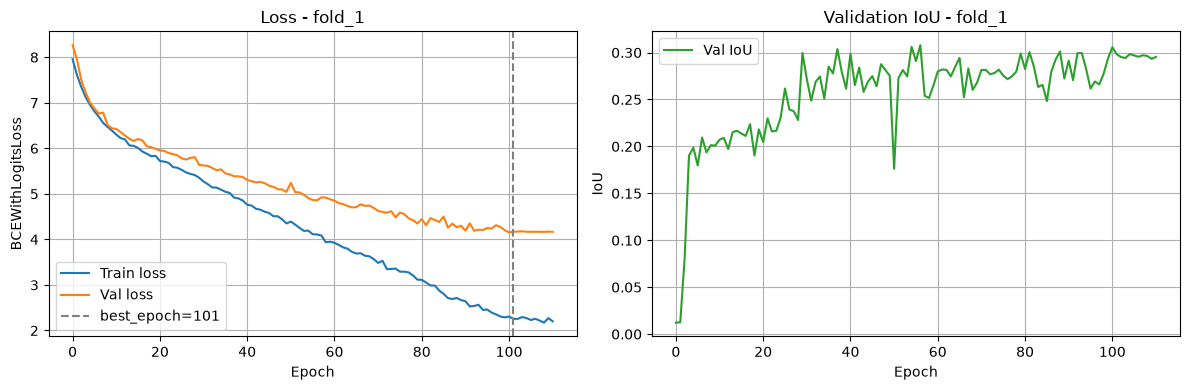

=== FOLD_1 ===
Train loss per epoch: [7.954172877378242, 7.607680609059888, 7.3423311654911485, 7.12034954026688, 6.953471793684849, 6.8132219314575195, 6.693302653556646, 6.556413528531096, 6.470659943514092, 6.389093842617301, 6.302113754804744, 6.223653493925583, 6.194994549418604, 6.063428490660911, 6.054562934609347, 6.005649533382682, 5.9289638275323915, 5.880828092264575, 5.826747750127038, 5.834446152975393, 5.721724310586619, 5.7085040890893275, 5.681542518527009, 5.588151965030404, 5.5724581784980245, 5.526641457579856, 5.470641136169434, 5.438081563905228, 5.412845034931982, 5.353027332660764, 5.269770799681198, 5.210651697114456, 5.140487160793571, 5.138381858204687, 5.091655631398046, 5.045744230580884, 5.020100427228351, 4.91733164011046, 4.899256961290226, 4.852005770040113, 4.761972516082054, 4.74353009600972, 4.673350478327552, 4.652070810628492, 4.608789022578749, 4.580834787945415, 4.507684031198191, 4.508445861727693, 4.440776758415755, 4.351232817006665, 4.39107174

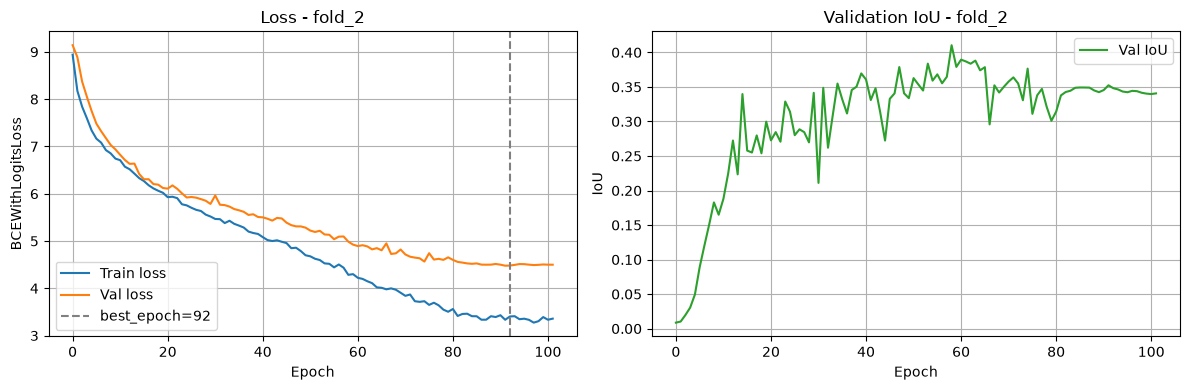

=== FOLD_2 ===
Train loss per epoch: [8.939334869384766, 8.174937414086383, 7.840467598127282, 7.595972807511039, 7.337879056515901, 7.164193982663362, 7.080798086912735, 6.922398463539455, 6.8538340692934785, 6.742871450341267, 6.708986365276834, 6.571534260459568, 6.517132613969886, 6.4249242285023564, 6.3301965672036875, 6.267717506574548, 6.178509546362835, 6.112393441407577, 6.0628720573757, 6.02014566504437, 5.927276549131974, 5.936291922693667, 5.90706087195355, 5.777164790941321, 5.753719640814739, 5.702626207600469, 5.659285358760668, 5.634494657101839, 5.557896634806758, 5.518401166667109, 5.466149164282757, 5.461818404819654, 5.379314775052278, 5.428394068842349, 5.3632228478141455, 5.326056293819262, 5.284850016884182, 5.199453851451045, 5.169177780980649, 5.149330740389616, 5.082243380339249, 5.020133847775667, 4.999874923540198, 5.014815537825875, 4.984175578407619, 4.956483633621879, 4.848095251166302, 4.85803106556768, 4.787694474925166, 4.698845759682033, 4.67652414156

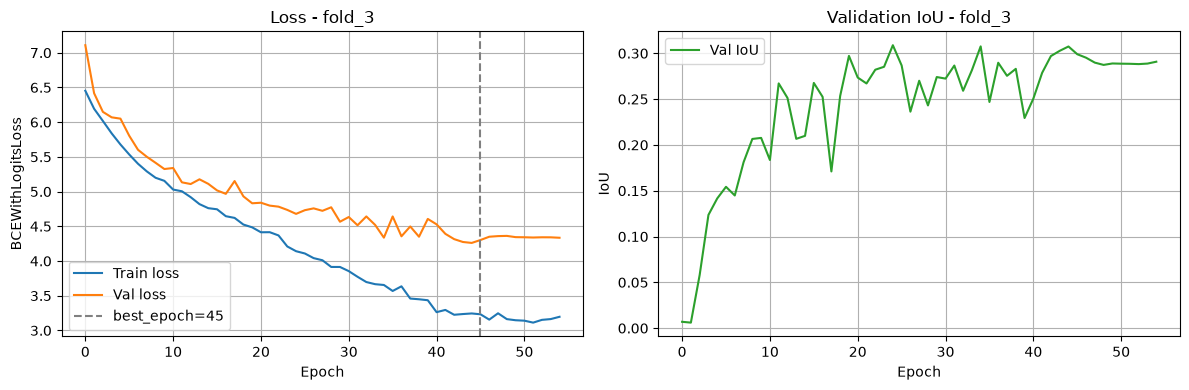

=== FOLD_3 ===
Train loss per epoch: [6.452048550481382, 6.192951098732326, 6.016987593277641, 5.838455469711967, 5.678423674210258, 5.534243770267652, 5.400622305662735, 5.2909481836401895, 5.198957298112952, 5.154723644256592, 5.029186518295951, 5.004297733306885, 4.919339553169582, 4.819433315940525, 4.761032643525497, 4.74500150265901, 4.645538288614024, 4.620791974275009, 4.525100438491158, 4.4849124369413955, 4.41390553764675, 4.41493442784185, 4.368441726850427, 4.209592217984407, 4.141202843707541, 4.108410026716149, 4.041569771973983, 4.01098486651545, 3.9144327640533447, 3.914197185765142, 3.854366167731907, 3.7727549801702085, 3.69718044737111, 3.6663205727286963, 3.6547405927077583, 3.5683643506920855, 3.6354238675988237, 3.459194162617559, 3.4489475644153096, 3.4350452112114946, 3.263230748798536, 3.295380219169285, 3.225675810938296, 3.2361231264860733, 3.244662264119024, 3.232709324878195, 3.155603854552559, 3.247116576070371, 3.1630262188289477, 3.1468005698660146, 3.14

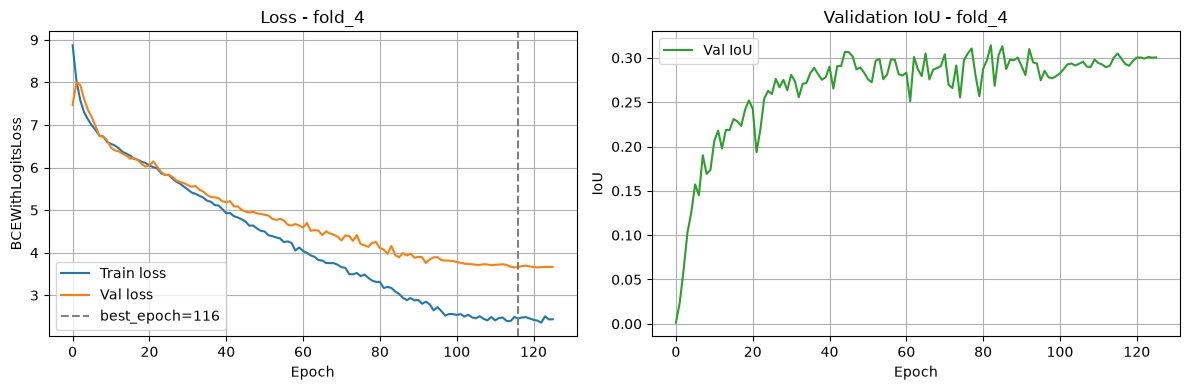

=== FOLD_4 ===
Train loss per epoch: [8.87508710901788, 8.033894457715624, 7.579466140016597, 7.296656983963986, 7.131791307571087, 6.988701059463176, 6.879907465995626, 6.749675050694892, 6.726977459927823, 6.599874232677704, 6.555620163045031, 6.517496738028019, 6.454349081566993, 6.368883021334384, 6.3270386736443704, 6.27880404857879, 6.202710800982536, 6.18149485486619, 6.134411842265028, 6.107348249313679, 6.049477922155502, 6.009432772372631, 5.981676040811742, 5.872865910225726, 5.829716550542953, 5.824924925540356, 5.739336439903746, 5.66760142306064, 5.617908954620361, 5.550986553760285, 5.483260032978464, 5.413329053432383, 5.381926901797031, 5.336857379751002, 5.296022567343204, 5.221814571542943, 5.196921906572707, 5.117879268970896, 5.107485192887326, 5.02338296809095, 4.926878705937812, 4.931456636875234, 4.856243975619052, 4.826379776000977, 4.783978492655653, 4.734186446413081, 4.632452082126699, 4.638953990124642, 4.567068536230859, 4.514402602581268, 4.49726031688933

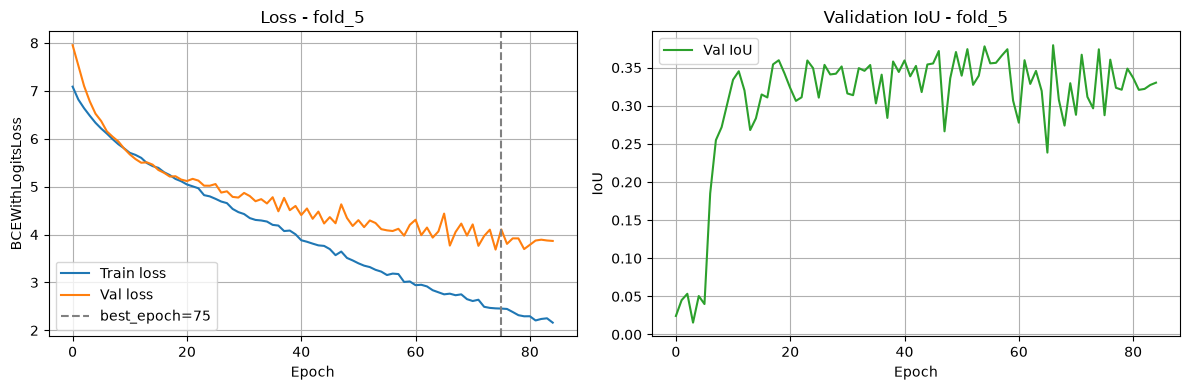

=== FOLD_5 ===
Train loss per epoch: [7.08780108327451, 6.8186639080876885, 6.638396055802055, 6.481452755306078, 6.333806639132292, 6.212601972662884, 6.106809470964515, 5.990863737852677, 5.88558234339175, 5.800281110017196, 5.7058427022851035, 5.662865161895752, 5.6013997119406, 5.49242987840072, 5.428848017816958, 5.392341800357984, 5.30105035201363, 5.241442016933275, 5.161117491514786, 5.112463805986487, 5.046076152635657, 5.006540277729863, 4.966357645781144, 4.822700065115224, 4.796816058780836, 4.745779721633248, 4.689285527104917, 4.655951106030008, 4.534554232721743, 4.468538056249204, 4.4280925833660625, 4.343717968982199, 4.305139831874682, 4.293643723363462, 4.271487184192823, 4.202018426812214, 4.187478760014409, 4.073230743408203, 4.08301359674205, 4.0052248602328095, 3.881392354550569, 3.8494353398032812, 3.8104084367337436, 3.7741577936255415, 3.763003349304199, 3.6962727671084195, 3.5697599493938945, 3.6448563907457436, 3.511783962664397, 3.4597819162451704, 3.399986

In [10]:
# Boucle sur les 5 folds de fold_histories
for i, (fold_name, history) in enumerate(fold_histories.items()):
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))
    
    # Récupération de la meilleure époque pour le fold courant (si disponible)
    current_best_epoch = history['best_epochs'][0] if 'best_epochs' in history and history['best_epochs'] else 0

    # 1. Loss plot (train vs val)
    axs[0].plot(history['train_loss'], label='Train loss')
    axs[0].plot(history['val_loss'], label='Val loss')
    if current_best_epoch > 0:
        axs[0].axvline(current_best_epoch, color='gray', linestyle='--', label=f'best_epoch={current_best_epoch}')
    axs[0].set_title(f'Loss - {fold_name}')
    axs[0].set_xlabel('Epoch')
    axs[0].set_ylabel('BCEWithLogitsLoss')
    axs[0].legend()
    axs[0].grid(True)

    # 2. Val IoU plot
    iou_key = 'val_iou_all' if 'val_iou_all' in history else 'val_iou'
    axs[1].plot(history[iou_key], label='Val IoU', color='tab:green')
    axs[1].set_title(f'Validation IoU - {fold_name}')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('IoU')
    axs[1].legend()
    axs[1].grid(True)

    plt.tight_layout()
    plt.show()

    # Afichage des logs pour le fold courant
    print(f"=== {fold_name.upper()} ===")
    print('Train loss per epoch:', history['train_loss'])
    print('Val loss per epoch:  ', history['val_loss'])
    print('Val IoU per epoch:   ', history[iou_key])
    print('=' * 50 + '\n')

### Sauvegarde des résultats

In [11]:
file_path = f'results_{MODEL_NAME}_{DATASET_NAME}.pkl'

# Sauvegarde de l'historique complet de tous les folds
with open(file_path, 'wb') as f:
    pickle.dump(fold_results, f)

## Résultats validation

Choisir un fold et l'index local d'une image, ou renseigner directement son nom de fichier. Seul le checkpoint correspondant est chargé et seule cette image est évaluée.

In [35]:
# ------------ 1. Choix de l'image -------------
# Mode historique : renseigner VIS_FOLD et VIS_INDEX.
# Mode direct : renseigner VIS_FILENAME avec le nom exact du fichier.
VIS_FILENAME = '0004722_11.07.19_357291_2019.jpg'  # Exemple : '0006931_10.06.55_426711_2024.jpg'
VIS_FOLD = 1  # Numéro du fold, entre 1 et k_folds
VIS_INDEX = 12  # Index de l'image dans le jeu de validation du fold (0 à len(val_indices)-1)


Nombre de folds disponibles : 5
Métriques pour 0004722_11.07.19_357291_2019.jpg — fold 1, index 1


,dice,iou,precision,recall,diff_surface (pixels)
classe,,,,,
Oeuf,0.6039,0.4325,0.5471,0.6737,1928.0000
Global,0.6039,0.4325,0.5471,0.6737,1928.0000


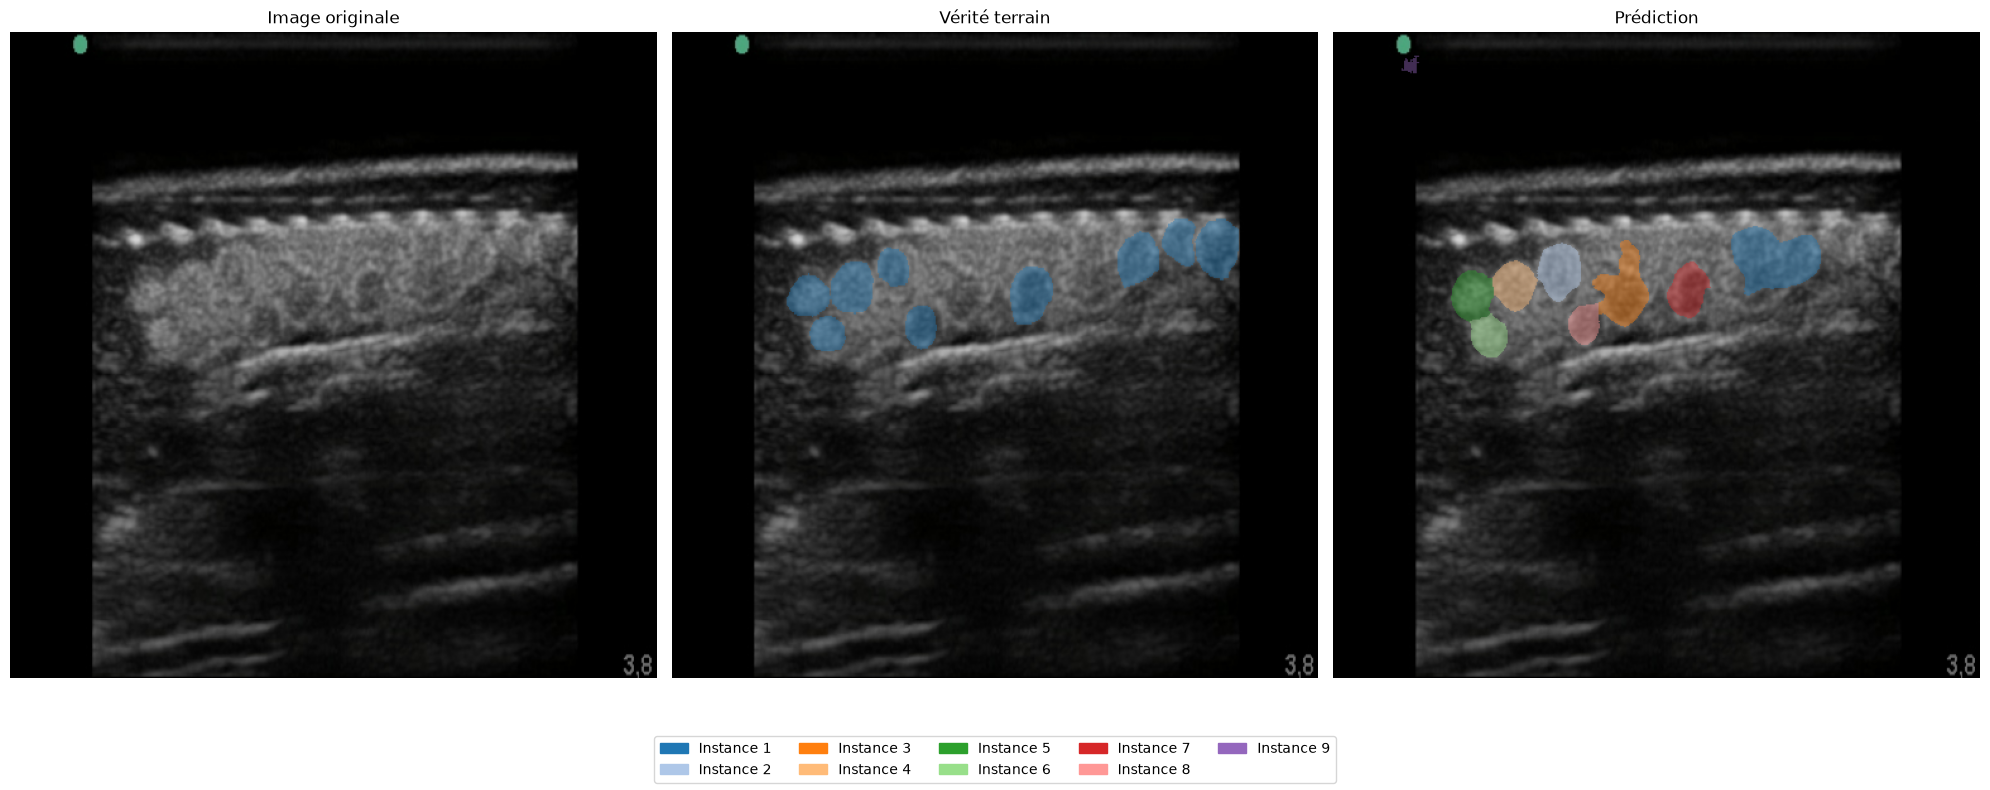

(<Figure size 2000x800 with 3 Axes>,
 array([<Axes: title={'center': 'Image originale'}>, <Axes: title={'center': 'Vérité terrain'}>, <Axes: title={'center': 'Prédiction'}>], dtype=object))

In [36]:
# ------------ 2. Reconstruction du fold de validation -------------
cv_splits = list(get_cv_splits())
print(f"Nombre de folds disponibles : {len(cv_splits)}")

if VIS_FILENAME is not None and str(VIS_FILENAME).strip():
    # Recherche exacte sur le nom du fichier, quel que soit le fold.
    requested_filename = Path(str(VIS_FILENAME).strip()).name
    filename_matches = []
    for fold_index, (_, val_indices_for_fold) in enumerate(cv_splits, start=1):
        val_indices_for_fold = np.asarray(val_indices_for_fold)
        for image_index, sample_index_for_match in enumerate(val_indices_for_fold):
            sample_for_match = cv_samples[int(sample_index_for_match)]
            sample_filename = Path(sample_for_match['image_info']['file_name']).name
            if sample_filename == requested_filename:
                filename_matches.append((fold_index, image_index, sample_index_for_match))

    if not filename_matches:
        raise FileNotFoundError(
            f"Fichier introuvable dans les folds de validation : {requested_filename}"
        )
    if len(filename_matches) > 1:
        matches = [(fold, index) for fold, index, _ in filename_matches]
        raise ValueError(
            f"Plusieurs correspondances trouvées pour {requested_filename} : {matches}"
        )

    VIS_FOLD, VIS_INDEX, sample_index = filename_matches[0]
    _, val_indices = cv_splits[VIS_FOLD - 1]
    val_indices = np.asarray(val_indices)
else:
    if not 1 <= VIS_FOLD <= len(cv_splits):
        raise ValueError(f"VIS_FOLD doit être compris entre 1 et {len(cv_splits)}.")

    _, val_indices = cv_splits[VIS_FOLD - 1]
    val_indices = np.asarray(val_indices)
    if not 0 <= VIS_INDEX < len(val_indices):
        raise IndexError(
            f"VIS_INDEX doit être compris entre 0 et {len(val_indices) - 1} "
            f"pour le fold {VIS_FOLD}."
        )

    sample_index = int(val_indices[VIS_INDEX])

# ------------ 3. Récupération des informations correspondantes -------------
sample = cv_samples[sample_index]
dataset_vis, _ = build_dataset([sample])
item = dataset_vis[0]
image_vis = item['image']
images = image_vis.unsqueeze(0).to(device)
masks = item['mask'].unsqueeze(0).to(device)
file_name = sample['image_info']['file_name']

# ------------ 4. Chargement du modèle et des probas -------------
checkpoint_path = Path(
    f"saves/unet_finetuned_fold_{VIS_FOLD}_{MODEL_NAME}_{DATASET_NAME}.pth"
)
if not checkpoint_path.exists():
    raise FileNotFoundError(f"Checkpoint introuvable : {checkpoint_path}")

model_eval = build_model().to(device)
model_eval.load_state_dict(torch.load(checkpoint_path, map_location=device))
model_eval.eval()
with torch.inference_mode():
    logits = model_eval(images)

# ------------ 5. Prédictions et post-traitement -------------
if MODEL_NAME == "EggSegmentationHVUNet":
    pred_mask, instance_labels = postprocess_egg_instances(logits[0])
    true = masks[:, :1] > 0.5
    preds = torch.from_numpy(pred_mask)[None, None].to(device=device, dtype=torch.bool)
    prediction_to_plot = torch.from_numpy(instance_labels)
else:
    valid_mask = masks != -100
    true = (masks > 0.5) & valid_mask
    preds = (torch.sigmoid(logits) > 0.5) & valid_mask

    # Post-traitement et division : oeufs
    if DATASET_NAME == "oeufs":
        instance_labels = split_eggs(preds,
          min_distance=8,
          min_area=100,
          ouverture_size=3,
          ouverture_iterations=1
          )
        prediction_to_plot = instance_labels[0].cpu()
        preds = (instance_labels > 0).unsqueeze(1)

    else:
        # Post-traitement : cavite, gonades et intestin
        if preds.shape[1] > 1:
            preds = keep_largest_components(preds)
            preds = fill_holes(preds)
        preds &= valid_mask
        prediction_to_plot = preds[0].cpu()

# ----------- 5. Récupération de l'échelle -------------
if DATASET_NAME == "oeufs":
    scale = 1.0
else:
    scale_rows = df.loc[df["image_id"] == file_name.split("_")[0], "echelle"]
    if scale_rows.empty:
        raise ValueError(f"Échelle introuvable pour {file_name}")
    scale = float(scale_rows.iloc[0])
scale_tensor = torch.tensor([[scale]], device=device, dtype=torch.float32)

# ----------- 6. Calcul des métriques par classe -------------
intersection, union, iou, dice, precision, recall, diff_surface = metrics_by_class(
    true, preds, scale_tensor, DATASET_NAME
)
true_area = true.sum(dim=(2, 3)).float()
pred_area = preds.sum(dim=(2, 3)).float()
empty = (true_area + pred_area) == 0
for metric in (iou, dice, precision, recall):
    metric[empty] = 1.0

metric_rows = []
for class_idx, class_name in enumerate(class_names):
    metric_rows.append({
        "classe": class_name,
        "dice": dice[0, class_idx].item(),
        "iou": iou[0, class_idx].item(),
        "precision": precision[0, class_idx].item(),
        "recall": recall[0, class_idx].item(),
        "diff_surface": diff_surface[0, class_idx].item(),
    })

intersection_global = intersection.sum()
union_global = union.sum()
true_global = true_area.sum()
pred_global = pred_area.sum()
metric_rows.append({
    "classe": "Global",
    "dice": (2 * intersection_global / (true_global + pred_global)).item() if true_global + pred_global > 0 else 1.0,
    "iou": (intersection_global / union_global).item() if union_global > 0 else 1.0,
    "precision": (intersection_global / pred_global).item() if pred_global > 0 else float(true_global == 0),
    "recall": (intersection_global / true_global).item() if true_global > 0 else float(pred_global == 0),
    "diff_surface": diff_surface.sum().item(),
})

metrics_table = pd.DataFrame(metric_rows).set_index('classe')
surface_unit = "pixels" if DATASET_NAME == "oeufs" else "cm²"
metrics_table = metrics_table.rename(columns={"diff_surface": f"diff_surface ({surface_unit})"})
print(f"Métriques pour {file_name} — fold {VIS_FOLD}, index {VIS_INDEX}")
display(metrics_table.style.format(precision=4))

# ----------- 7. Affichage de l'image, du masque réel et de la prédiction ------
plot_segmentation_comparison(
    image_vis, true[0].cpu(), prediction_to_plot,
    is_eggs=DATASET_NAME == "oeufs", alpha=0.45,
)